In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [58]:
df = pd.read_csv('/content/drive/MyDrive/Python/dirty_data.csv')
df.head()

,order_id,customer_id,date,nearest_warehouse,shopping_cart,order_price,delivery_charges,customer_lat,customer_long,coupon_discount,order_total,season,is_expedited_delivery,distance_to_nearest_warehouse,latest_customer_review,is_happy_customer
0,ORD182494,ID6197211592,2019-06-22,Thompson,"[('Lucent 330S', 1), ('Thunder line', 2), ('iS...",12200,79.89,-37.815105,144.932843,10,11059.89,Winter,True,1.2800,perfect phone and trusted seller. phone itself...,True
1,ORD395518,ID0282825849,2019-12-29,Thompson,"[('Thunder line', 1), ('Universe Note', 2)]",9080,62.71,-37.802736,144.951118,0,9142.71,Summer,False,1.1621,it keeps dropping calls the wifi don't work th...,False
2,ORD494479,ID0579391891,2019-03-02,Nickolson,"[('Thunder line', 1), ('pearTV', 2)]",10670,65.87,-37.821302,144.957581,10,9668.87,Autumn,False,1.0949,five stars this is a great cheap phone.,True
3,ORD019224,ID4544561904,2019-01-12,Nickolson,"[('Universe Note', 1), ('Alcon 10', 2), ('Oliv...",24800,57.61,-37.811416,144.973073,15,21137.61,Summer,False,0.8571,charger did not fit the charger didn't fit.,False
4,ORD104032,ID6231506320,2019-11-28,Nickolson,"[('Universe Note', 1), ('Olivia x460', 1), ('i...",9145,75.54,37.823859,144.969892,25,6934.29,Spring,False,0.5867,four stars good,True


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       500 non-null    object 
 1   customer_id                    500 non-null    object 
 2   date                           500 non-null    object 
 3   nearest_warehouse              500 non-null    object 
 4   shopping_cart                  500 non-null    object 
 5   order_price                    500 non-null    int64  
 6   delivery_charges               500 non-null    float64
 7   customer_lat                   500 non-null    float64
 8   customer_long                  500 non-null    float64
 9   coupon_discount                500 non-null    int64  
 10  order_total                    500 non-null    float64
 11  season                         500 non-null    object 
 12  is_expedited_delivery          500 non-null    boo

In [60]:
df.duplicated().sum()

np.int64(0)

In [61]:
df = df.drop(['order_id', 'customer_id', 'date', 'shopping_cart', 'customer_lat', 'customer_long', 'latest_customer_review'], axis=1)

In [54]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
df.head()

,nearest_warehouse,order_price,delivery_charges,coupon_discount,order_total,season,is_expedited_delivery,distance_to_nearest_warehouse,is_happy_customer
0,Thompson,12200,79.89,10,11059.89,Winter,True,1.2800,True
1,Thompson,9080,62.71,0,9142.71,Summer,False,1.1621,False
2,Nickolson,10670,65.87,10,9668.87,Autumn,False,1.0949,True
3,Nickolson,24800,57.61,15,21137.61,Summer,False,0.8571,False
4,Nickolson,9145,75.54,25,6934.29,Spring,False,0.5867,True


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   nearest_warehouse              500 non-null    object 
 1   order_price                    500 non-null    int64  
 2   delivery_charges               500 non-null    float64
 3   coupon_discount                500 non-null    int64  
 4   order_total                    500 non-null    float64
 5   season                         500 non-null    object 
 6   is_expedited_delivery          500 non-null    bool   
 7   distance_to_nearest_warehouse  500 non-null    float64
 8   is_happy_customer              500 non-null    bool   
dtypes: bool(2), float64(3), int64(2), object(2)
memory usage: 28.4+ KB


In [64]:
df['expected_order_total'] = ( df['order_price'] * (100 - df['coupon_discount']) / 100 + df['delivery_charges'] )
df = df[ df['order_total'] == df['expected_order_total']]
df.drop(columns=['expected_order_total'], inplace=True)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 460 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   nearest_warehouse              460 non-null    object 
 1   order_price                    460 non-null    int64  
 2   delivery_charges               460 non-null    float64
 3   coupon_discount                460 non-null    int64  
 4   order_total                    460 non-null    float64
 5   season                         460 non-null    object 
 6   is_expedited_delivery          460 non-null    bool   
 7   distance_to_nearest_warehouse  460 non-null    float64
 8   is_happy_customer              460 non-null    bool   
dtypes: bool(2), float64(3), int64(2), object(2)
memory usage: 29.6+ KB


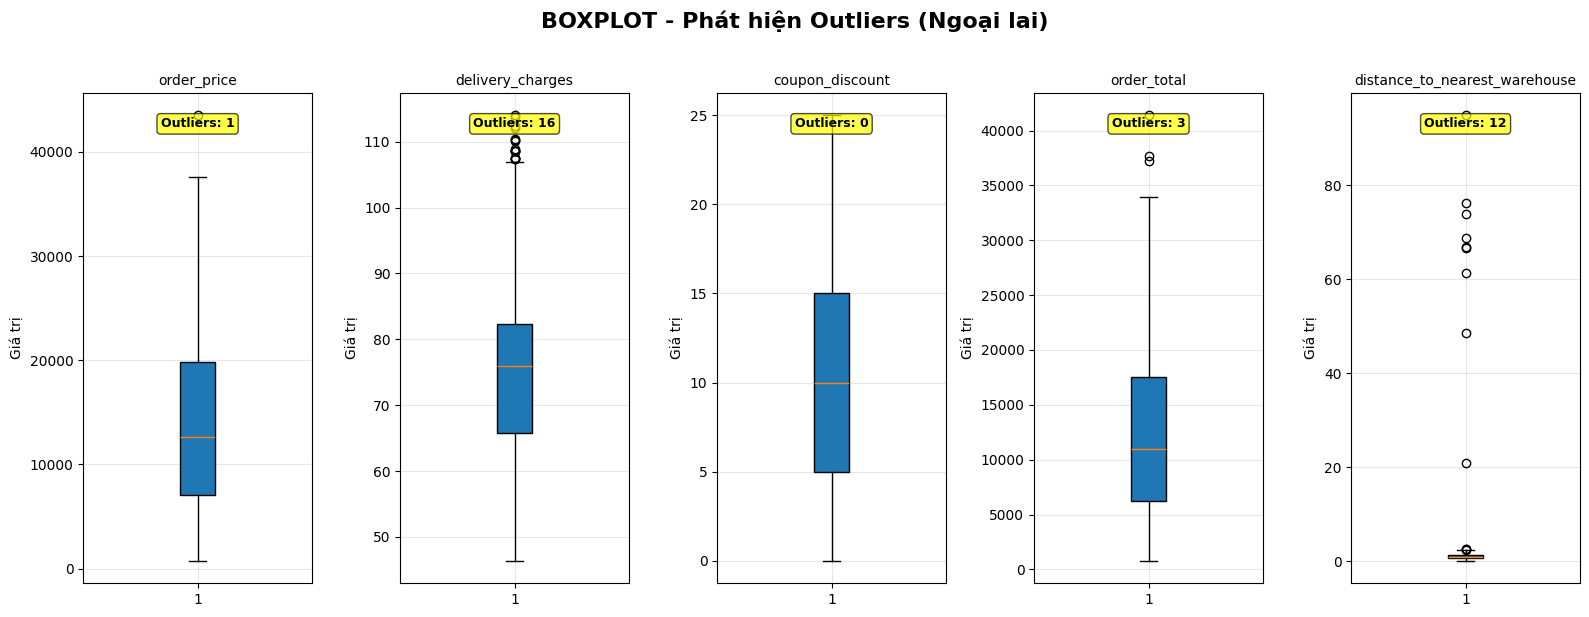

In [66]:
numerical_cols = [
    'order_price',
    'delivery_charges',
    'coupon_discount',
    'order_total',
    'distance_to_nearest_warehouse'
]
plt.figure(figsize=(16, 6))
plt.suptitle('BOXPLOT - Phát hiện Outliers (Ngoại lai)', fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 5, i)

    plt.boxplot(df[col].dropna(), patch_artist=True)
    plt.title(col, fontsize=10)
    plt.ylabel('Giá trị')
    plt.grid(True, alpha=0.3)

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)][col]

    plt.text(0.5, 0.95, f'Outliers: {len(outliers)}',
             transform=plt.gca().transAxes,
             ha='center', va='top',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [67]:
Q1 = df['distance_to_nearest_warehouse'].quantile(0.25)
Q3 = df['distance_to_nearest_warehouse'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

df= df[df[col] <= upper_bound].copy()

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 448 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   nearest_warehouse              448 non-null    object 
 1   order_price                    448 non-null    int64  
 2   delivery_charges               448 non-null    float64
 3   coupon_discount                448 non-null    int64  
 4   order_total                    448 non-null    float64
 5   season                         448 non-null    object 
 6   is_expedited_delivery          448 non-null    bool   
 7   distance_to_nearest_warehouse  448 non-null    float64
 8   is_happy_customer              448 non-null    bool   
dtypes: bool(2), float64(3), int64(2), object(2)
memory usage: 28.9+ KB


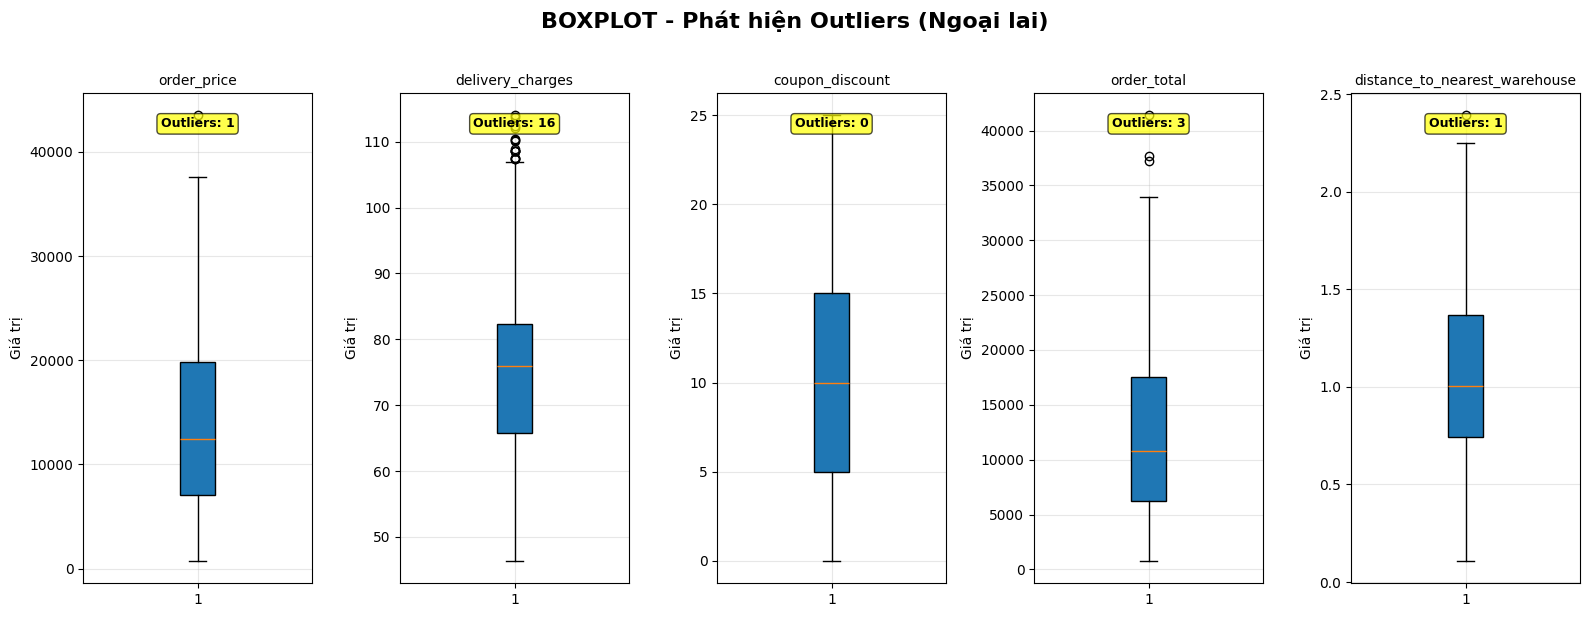

In [69]:
numerical_cols = [
    'order_price',
    'delivery_charges',
    'coupon_discount',
    'order_total',
    'distance_to_nearest_warehouse'
]

plt.figure(figsize=(16, 6))
plt.suptitle('BOXPLOT - Phát hiện Outliers (Ngoại lai)',
             fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 5, i)

    plt.boxplot(df[col].dropna(), patch_artist=True)
    plt.title(col, fontsize=10)
    plt.ylabel('Giá trị')
    plt.grid(True, alpha=0.3)

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)][col]

    plt.text(0.5, 0.95, f'Outliers: {len(outliers)}',
             transform=plt.gca().transAxes,
             ha='center', va='top',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 448 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   nearest_warehouse              448 non-null    object 
 1   order_price                    448 non-null    int64  
 2   delivery_charges               448 non-null    float64
 3   coupon_discount                448 non-null    int64  
 4   order_total                    448 non-null    float64
 5   season                         448 non-null    object 
 6   is_expedited_delivery          448 non-null    bool   
 7   distance_to_nearest_warehouse  448 non-null    float64
 8   is_happy_customer              448 non-null    bool   
dtypes: bool(2), float64(3), int64(2), object(2)
memory usage: 28.9+ KB


In [71]:
df['nearest_warehouse'].value_counts()

,count
nearest_warehouse,
Nickolson,170
Thompson,166
Bakers,105
thompson,4
nickolson,3


In [72]:
df['nearest_warehouse'] = df['nearest_warehouse'].str.capitalize()

In [73]:
df['nearest_warehouse'].value_counts()

,count
nearest_warehouse,
Nickolson,173
Thompson,170
Bakers,105


In [74]:
df['season'].value_counts()

,count
season,
Spring,121
Autumn,112
Summer,102
Winter,101
winter,5
autumn,3
summer,3
spring,1


In [75]:
df['season'] = df['season'].str.capitalize()

In [76]:
df['season'].value_counts()

,count
season,
Spring,122
Autumn,115
Winter,106
Summer,105


In [77]:
df['is_expedited_delivery'].value_counts()

,count
is_expedited_delivery,
True,225
False,223


In [78]:
df['is_happy_customer'].value_counts()

,count
is_happy_customer,
True,320
False,128


In [79]:
from sklearn.model_selection import train_test_split

In [80]:
X = df.drop(['order_total', 'is_happy_customer'], axis=1)
Y = df[['is_happy_customer']]

In [81]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify = Y, random_state=42)

In [82]:
df['nearest_warehouse'].value_counts()

,count
nearest_warehouse,
Nickolson,173
Thompson,170
Bakers,105


In [83]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

In [84]:
onehot_encoder = OneHotEncoder( sparse_output=False, handle_unknown='ignore')

onehot_encoder.fit(X_train[['nearest_warehouse']])

encoded_cols = onehot_encoder.get_feature_names_out(['nearest_warehouse'])

train_encoded = onehot_encoder.transform(X_train[['nearest_warehouse']])
train_encoded_df = pd.DataFrame(
    train_encoded,
    columns=encoded_cols,
    index=X_train.index
)

X_train = pd.concat([X_train.drop('nearest_warehouse', axis=1), train_encoded_df], axis=1)

test_encoded = onehot_encoder.transform(X_test[['nearest_warehouse']])
test_encoded_df = pd.DataFrame(
    test_encoded,
    columns=encoded_cols,
    index=X_test.index
)

X_test = pd.concat([X_test.drop('nearest_warehouse', axis=1), test_encoded_df], axis=1)

In [85]:
season_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

season_encoder.fit(X_train[['season']])

season_cols = season_encoder.get_feature_names_out(['season'])

season_train_encoded = season_encoder.transform(X_train[['season']])
season_train_df = pd.DataFrame(
    season_train_encoded,
    columns=season_cols,
    index=X_train.index
)

X_train = pd.concat([X_train.drop('season', axis=1), season_train_df], axis=1)

season_test_encoded = season_encoder.transform(X_test[['season']])
season_test_df = pd.DataFrame(
    season_test_encoded,
    columns=season_cols,
    index=X_test.index
)

X_test = pd.concat([X_test.drop('season', axis=1), season_test_df], axis=1)

In [86]:
from sklearn.preprocessing import OrdinalEncoder
expedite_encoder = OrdinalEncoder(categories=[[False, True]])
expedite_encoder.fit(X_train[['is_expedited_delivery']])
X_train['is_expedited_delivery'] = expedite_encoder.transform( X_train[['is_expedited_delivery']])
X_test['is_expedited_delivery'] = expedite_encoder.transform( X_test[['is_expedited_delivery']])

In [87]:
X_train.head()

,order_price,delivery_charges,coupon_discount,is_expedited_delivery,distance_to_nearest_warehouse,nearest_warehouse_Bakers,nearest_warehouse_Nickolson,nearest_warehouse_Thompson,season_Autumn,season_Spring,season_Summer,season_Winter
124,17260,64.30,15,0.0,0.9631,1.0,0.0,0.0,0.0,0.0,0.0,1.0
166,8770,65.06,15,0.0,0.9345,1.0,0.0,0.0,0.0,0.0,0.0,1.0
215,22650,79.74,15,0.0,1.4087,1.0,0.0,0.0,1.0,0.0,0.0,0.0
342,24680,76.85,25,1.0,0.9396,0.0,0.0,1.0,0.0,0.0,0.0,1.0
321,15800,61.64,10,0.0,0.1459,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [88]:
df['is_happy_customer'].value_counts()

,count
is_happy_customer,
True,320
False,128


In [89]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder(categories=[[False, True]])
ordinal_encoder.fit(pd.DataFrame(Y_train['is_happy_customer']))
Y_train['is_happy_customer'] = ordinal_encoder.transform(pd.DataFrame(Y_train['is_happy_customer']))
Y_test['is_happy_customer'] = ordinal_encoder.transform(pd.DataFrame(Y_test['is_happy_customer']))

In [90]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

print("Before Oversampling:")
print(Y_train.value_counts())

ros = RandomOverSampler(random_state=42)

X_train, Y_train = ros.fit_resample(
    X_train,
    Y_train.values.ravel()
)

Y_train = pd.Series(Y_train, name="is_happy_customer")

print("\nAfter Oversampling:")
print(Y_train.value_counts())

Before Oversampling:
is_happy_customer
1.0                  256
0.0                  102
Name: count, dtype: int64

After Oversampling:
is_happy_customer
1.0    256
0.0    256
Name: count, dtype: int64


In [91]:
X_train_non = X_train.copy()
X_test_non = X_test.copy()

In [92]:
from sklearn.preprocessing import StandardScaler

num_cols = [
    'order_price',
    'delivery_charges',
    'coupon_discount',
    'distance_to_nearest_warehouse'
]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test[num_cols] = scaler.transform(X_test[num_cols])

In [93]:
X_train

,order_price,delivery_charges,coupon_discount,is_expedited_delivery,distance_to_nearest_warehouse,nearest_warehouse_Bakers,nearest_warehouse_Nickolson,nearest_warehouse_Thompson,season_Autumn,season_Spring,season_Summer,season_Winter
0,0.365401,-0.663816,0.489260,0.0,-0.240985,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.643399,-0.612629,0.489260,0.0,-0.303698,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.005853,0.376089,0.489260,0.0,0.736097,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.247062,0.181444,1.633101,1.0,-0.292515,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.191921,-0.842971,-0.082660,0.0,-2.032888,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
507,-0.555471,-0.856441,1.633101,0.0,-0.431753,1.0,0.0,0.0,0.0,1.0,0.0,0.0
508,0.942877,-0.799193,-1.226501,1.0,-1.539084,0.0,1.0,0.0,1.0,0.0,0.0,0.0
509,0.090922,1.812021,0.489260,1.0,-0.321897,0.0,0.0,1.0,0.0,1.0,0.0,0.0
510,0.425407,-0.417310,0.489260,0.0,1.053166,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [94]:
Y_train

,is_happy_customer
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
507,0.0
508,0.0
509,0.0
510,0.0


In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [96]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

In [97]:
# Khởi tạo mô hình Logistic Regression
logreg = LogisticRegression(max_iter=1000)

In [98]:
# Huấn luyện mô hình trên dữ liệu huấn luyện
logreg.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

In [99]:
# Dự đoán kết quả trên dữ liệu kiểm tra
Y_pred_logreg = logreg.predict(X_test)
Y_pred_proba_logreg = logreg.predict_proba(X_test)[:, 1]

In [100]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=99, max_depth=10, random_state=42)
rf.fit(X_train_non, Y_train)

RandomForestClassifier(max_depth=10, n_estimators=99, random_state=42)

In [101]:
Y_pred_rf = rf.predict(X_test_non)
Y_pred_proba_rf = rf.predict_proba(X_test_non)[:, 1]

In [102]:
from sklearn.svm import SVC
svm_model = SVC(
    kernel='rbf',        # RBF kernel (phổ biến nhất)
    C=1.0,               # Regularization parameter
    gamma='scale',       # Kernel coefficient (auto)
    probability=True,    # BẮT BUỘC để tính ROC-AUC
    random_state=42
)
svm_model.fit(X_train, Y_train)

SVC(probability=True, random_state=42)

In [103]:
Y_pred_svm = svm_model.predict(X_test)
Y_pred_proba_svm = svm_model.predict_proba(X_test)[:, 1]

In [104]:
def evaluate_model(Y_test, Y_pred, Y_pred_proba, model_name):
    conf = confusion_matrix(Y_test, Y_pred)
    acc = accuracy_score(Y_test, Y_pred)
    prec = precision_score(Y_test, Y_pred)
    rec = recall_score(Y_test, Y_pred)
    f1 = f1_score(Y_test, Y_pred)
    auc = roc_auc_score(Y_test, Y_pred_proba)

    print(f"\n{model_name}:")
    print("Confusion Matrix:")
    print(conf)
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")

    return [model_name, conf, acc, prec, rec, f1, auc]

In [105]:
results = []
results.append(evaluate_model(Y_test, Y_pred_logreg, Y_pred_proba_logreg, "Logistic Regression"))
results.append(evaluate_model(Y_test, Y_pred_rf, Y_pred_proba_rf, "Random Forest"))
results.append(evaluate_model(Y_test, Y_pred_svm, Y_pred_proba_svm, "SVM"))


Logistic Regression:
Confusion Matrix:
[[23  3]
 [ 3 61]]
Accuracy:  0.9333
Precision: 0.9531
Recall:    0.9531
F1-Score:  0.9531
ROC-AUC:   0.9032

Random Forest:
Confusion Matrix:
[[17  9]
 [ 3 61]]
Accuracy:  0.8667
Precision: 0.8714
Recall:    0.9531
F1-Score:  0.9104
ROC-AUC:   0.8846

SVM:
Confusion Matrix:
[[21  5]
 [ 2 62]]
Accuracy:  0.9222
Precision: 0.9254
Recall:    0.9688
F1-Score:  0.9466
ROC-AUC:   0.9117


In [106]:
results

[['Logistic Regression',
  array([[23,  3],
         [ 3, 61]]),
  0.9333333333333333,
  0.953125,
  0.953125,
  0.953125,
  np.float64(0.9032451923076923)],
 ['Random Forest',
  array([[17,  9],
         [ 3, 61]]),
  0.8666666666666667,
  0.8714285714285714,
  0.953125,
  0.9104477611940298,
  np.float64(0.8846153846153846)],
 ['SVM',
  array([[21,  5],
         [ 2, 62]]),
  0.9222222222222223,
  0.9253731343283582,
  0.96875,
  0.9465648854961832,
  np.float64(0.9116586538461539)]]

In [107]:
comparison_df = pd.DataFrame(results, columns=[
    'Model', 'Confusion Matrix', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'
])
print(comparison_df.to_string(index=False))

              Model   Confusion Matrix  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression [[23, 3], [3, 61]]  0.933333   0.953125 0.953125  0.953125 0.903245
      Random Forest [[17, 9], [3, 61]]  0.866667   0.871429 0.953125  0.910448 0.884615
                SVM [[21, 5], [2, 62]]  0.922222   0.925373 0.968750  0.946565 0.911659


In [108]:
metrics_to_rank = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
rank_df = comparison_df[['Model']].copy()

for metric in metrics_to_rank:
    rank_df[f'{metric}_Rank'] = comparison_df[metric].rank(ascending=False)

rank_columns = [col for col in rank_df.columns if '_Rank' in col]
rank_df['Total_Rank'] = rank_df[rank_columns].sum(axis=1)

print("Ranking Table:")
print(rank_df.to_string(index=False))

best_idx_rank = rank_df['Total_Rank'].idxmin()
best_model_rank = rank_df.loc[best_idx_rank, 'Model']
best_rank = rank_df.loc[best_idx_rank, 'Total_Rank']

print(f"BEST MODEL:")
print(f"   {best_model_rank}")

Ranking Table:
              Model  Accuracy_Rank  Precision_Rank  Recall_Rank  F1-Score_Rank  ROC-AUC_Rank  Total_Rank
Logistic Regression            1.0             1.0          2.5            1.0           2.0         7.5
      Random Forest            3.0             3.0          2.5            3.0           3.0        14.5
                SVM            2.0             2.0          1.0            2.0           1.0         8.0
BEST MODEL:
   Logistic Regression


XẾP HẠNG YẾU TỐ ẢNH HƯỞNG NHẤT (Logistic Regression):
                      Feature  Coefficient  Abs_Coefficient
        is_expedited_delivery    -4.626347         4.626347
             delivery_charges     3.876590         3.876590
                season_Spring    -2.903995         2.903995
                season_Winter     2.200832         2.200832
                season_Autumn     1.560969         1.560969
distance_to_nearest_warehouse    -0.953855         0.953855
                season_Summer    -0.856613         0.856613
  nearest_warehouse_Nickolson     0.222378         0.222378
   nearest_warehouse_Thompson    -0.166309         0.166309
              coupon_discount    -0.117536         0.117536
                  order_price    -0.075149         0.075149
     nearest_warehouse_Bakers    -0.054874         0.054874


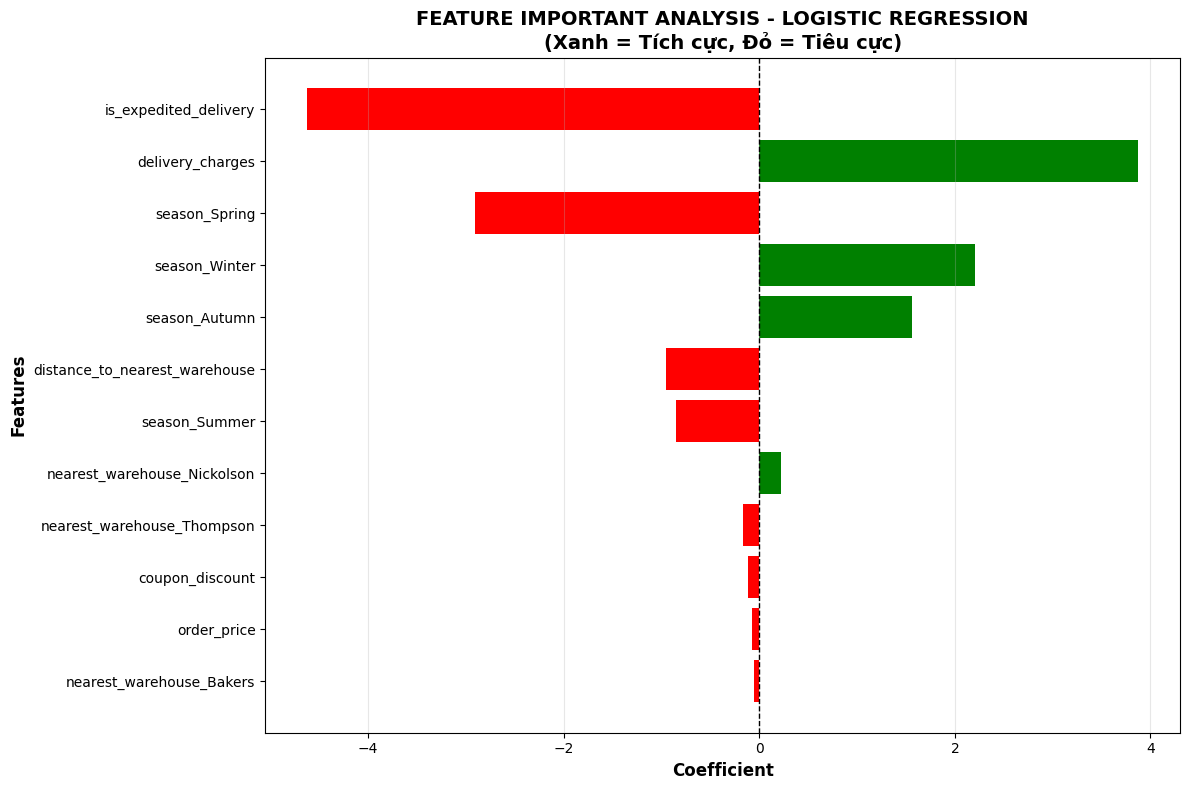

In [109]:
feature_importance_lr = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': logreg.coef_[0],
    'Abs_Coefficient': np.abs(logreg.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("XẾP HẠNG YẾU TỐ ẢNH HƯỞNG NHẤT (Logistic Regression):")
print(feature_importance_lr.head(13).to_string(index=False))

plt.figure(figsize=(12, 8))
top_features_lr = feature_importance_lr.head(15)

colors = ['green' if x > 0 else 'red' for x in top_features_lr['Coefficient']]
plt.barh(range(len(top_features_lr)), top_features_lr['Coefficient'], color=colors)
plt.yticks(range(len(top_features_lr)), top_features_lr['Feature'])
plt.xlabel('Coefficient', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('FEATURE IMPORTANT ANALYSIS - LOGISTIC REGRESSION\n(Xanh = Tích cực, Đỏ = Tiêu cực)',
         fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

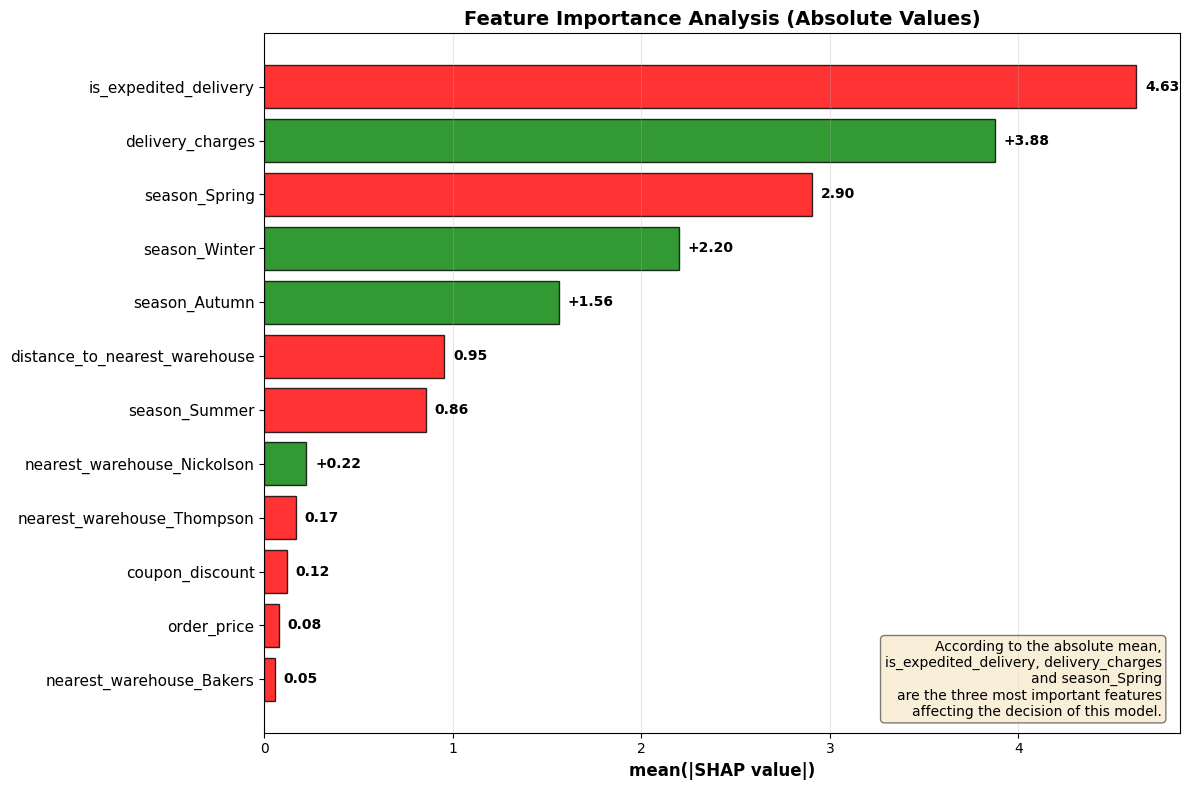

In [110]:
feature_names = X_train.columns
coefficients = logreg.coef_[0]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

plt.figure(figsize=(12, 8))
top = importance_df.head(13).copy()

colors = ['green' if x > 0 else 'red' for x in top['Coefficient']]
plt.barh(range(len(top)), top['Abs_Coefficient'], color=colors, edgecolor='black', alpha=0.8)

for i, (idx, row) in enumerate(top.iterrows()):
    value = row['Abs_Coefficient']
    plt.text(value + max(top['Abs_Coefficient'])*0.01, i,
            f'+{value:.2f}' if row['Coefficient'] > 0 else f'{value:.2f}',
            va='center', fontweight='bold', fontsize=10)

plt.yticks(range(len(top)), top['Feature'], fontsize=11)
plt.xlabel('mean(|SHAP value|)', fontsize=12, fontweight='bold')
plt.title('Feature Importance Analysis (Absolute Values)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.gca().invert_yaxis()

plt.text(0.98, 0.02,
        f'According to the absolute mean,\n{top.iloc[0]["Feature"]}, {top.iloc[1]["Feature"]}\nand {top.iloc[2]["Feature"]}\nare the three most important features\naffecting the decision of this model.',
        transform=plt.gca().transAxes,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        verticalalignment='bottom', horizontalalignment='right',
        fontsize=10)

plt.tight_layout()
plt.show()